In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Destiny's To Do:

- [x] Reclassify core/peripheral stations using data-driven approach
- [x] Investigate Downtown Berkeley Census Data
- [x] Visualizations
- [x] Missing data (report)
- [] Clean up code (put notebook code into python file)


## New Transit Data

In [3]:
transit = pd.read_csv('../data/transit_gdf.csv')
transit

,Unnamed: 0,station_id,name,latitude,longitude,address,city,county,zipcode,agency,mode,geometry
0,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768)
1,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062)
2,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835)
3,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247)
4,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388)
...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384)
77,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416)
78,78,stanford,Stanford,37.438950,-122.157150,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.15715 37.43895)
79,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934)


In [4]:
transit['name'].values

<StringArray>
[        '12th St. Oakland City Center',
                     '16th St. Mission',
                     '19th St. Oakland',
                     '24th St. Mission',
                              'Antioch',
                                'Ashby',
                          'Balboa Park',
                             'Bay Fair',
             'Berryessa/North San Jose',
                        'Castro Valley',
                'Civic Center/UN Plaza',
                             'Coliseum',
                                'Colma',
                              'Concord',
                            'Daly City',
                    'Downtown Berkeley',
                    'Dublin/Pleasanton',
                 'El Cerrito del Norte',
                     'El Cerrito Plaza',
                          'Embarcadero',
                              'Fremont',
                            'Fruitvale',
                            'Glen Park',
                              'Hayward',
  

In [5]:
duplicated_station = transit['name'].duplicated()
transit.loc[duplicated_station, 'name'] = 'Millbrae Caltrain Station'

In [6]:
classification = pd.read_csv('../output/classification_results_fy2025.csv')
classification = classification.rename(columns = {'consensus' : "station_type"})
classification

,station,agency,fiscal_year,metric,avg_weekday_exits,rank,method_percentile,method_zscore,method_kmeans,method_jenks,core_votes,station_type
0,Embarcadero,BART,FY2025,avg_weekday_exits,17500,1,core,core,core,core,4,core
1,Montgomery St.,BART,FY2025,avg_weekday_exits,15800,2,core,core,core,core,4,core
2,Civic Center/UN Plaza,BART,FY2025,avg_weekday_exits,13500,3,core,core,core,core,4,core
3,Powell St.,BART,FY2025,avg_weekday_exits,13200,4,core,core,core,core,4,core
4,24th St. Mission,BART,FY2025,avg_weekday_exits,8200,5,core,core,core,core,4,core
...,...,...,...,...,...,...,...,...,...,...,...,...
77,Capitol,Caltrain,FY2025,avg_mid_week_ridership_AMWR,80,78,peripheral,peripheral,peripheral,peripheral,0,peripheral
78,Broadway,Caltrain,FY2025,avg_mid_week_ridership_AMWR,60,79,peripheral,peripheral,peripheral,peripheral,0,peripheral
79,College Park,Caltrain,FY2025,avg_mid_week_ridership_AMWR,50,80,peripheral,peripheral,peripheral,peripheral,0,peripheral
80,San Martin,Caltrain,FY2025,avg_mid_week_ridership_AMWR,40,81,peripheral,peripheral,peripheral,peripheral,0,peripheral


In [7]:
classification['station_id'] = classification['station'] + '_' + classification['agency']
classification['station_id'].values

<StringArray>
[                      'Embarcadero_BART',
                    'Montgomery St._BART',
             'Civic Center/UN Plaza_BART',
                        'Powell St._BART',
                  '24th St. Mission_BART',
                 'San Francisco_Caltrain',
      '12th St. Oakland City Center_BART',
                  '19th St. Oakland_BART',
                          'Millbrae_BART',
                      'Walnut Creek_BART',
                 'Downtown Berkeley_BART',
                         'Daly City_BART',
                      'Lake Merritt_BART',
                         'Fruitvale_BART',
             'San Francisco Airport_BART',
                 'Dublin/Pleasanton_BART',
                         'Rockridge_BART',
                           'Fremont_BART',
                         'MacArthur_BART',
 'Pleasant Hill/Contra Costa Centre_BART',
                          'Coliseum_BART',
                  '16th St. Mission_BART',
                          'Bay Fair_BART

In [8]:
list(set(transit['name'].values) ^ set(classification['station'].values)) 


['San Francisco',
 'Oakland International Airport',
 'Tamien',
 'Tamien Caltrain Station',
 'El Cerrito del Norte',
 'Capitol Caltrain Station',
 'Berryessa/North San Jose',
 'Blossom Hill',
 'Blossom Hill Caltrain Station',
 'Santa Clara Caltrain Station',
 'South San Francisco Caltrain Station',
 'El Cerrito Del Norte',
 'San Bruno Caltrain Station',
 'Capitol',
 'California Avenue',
 'Santa Clara',
 'Berryessa/North San José',
 'San Francisco Caltrain Station',
 'California Ave',
 'Oakland Airport',
 'Millbrae Caltrain Station',
 'San Francisco Airport',
 'San Francisco International Airport']

In [9]:
classification['station_id'] = classification['station_id'].replace({
               'Embarcadero_BART' : 'Embarcadero',                    
               'Montgomery St._BART' : 'Montgomery St.',
               'Civic Center/UN Plaza_BART' : 'Civic Center/UN Plaza',                        
               'Powell St._BART' : 'Powell St.',
               '24th St. Mission_BART' : '24th St. Mission',                     
               'San Francisco_Caltrain' : 'San Francisco Caltrain Station',
               '12th St. Oakland City Center_BART' : '12th St. Oakland City Center',                  
               '19th St. Oakland_BART' : '19th St. Oakland',
               'Millbrae_BART' : 'Millbrae',                      
               'Walnut Creek_BART' : 'Walnut Creek',
               'Downtown Berkeley_BART' : 'Downtown Berkeley',                         
               'Daly City_BART' : 'Daly City',
               'Lake Merritt_BART' : 'Lake Merritt',                         
               'Fruitvale_BART' : 'Fruitvale',
               'San Francisco Airport_BART' : 'San Francisco International Airport',                 
               'Dublin/Pleasanton_BART' : 'Dublin/Pleasanton',
               'Rockridge_BART' : 'Rockridge',                           
               'Fremont_BART' : 'Fremont',
               'MacArthur_BART' : 'MacArthur', 
               'Pleasant Hill/Contra Costa Centre_BART' : 'Pleasant Hill/Contra Costa Centre',
               'Coliseum_BART' : 'Coliseum',                  
               '16th St. Mission_BART' : '16th St. Mission',
               'Bay Fair_BART' : 'Bay Fair',              
               'El Cerrito Del Norte_BART' : 'El Cerrito del Norte',
               'Concord_BART' : 'Concord',                      
               'West Oakland_BART' : 'West Oakland',
               'San Jose Diridon_Caltrain' : 'San Jose Diridon',                       
               'San Leandro_BART' : 'San Leandro',
               'Balboa Park_BART' : 'Balboa Park',                         
               'Glen Park_BART' : 'Glen Park',
               'Berryessa/North San José_BART' : 'Berryessa/North San Jose',                         
               'Palo Alto_Caltrain' : 'Palo Alto',
               'Hayward_BART' : 'Hayward',                         
               'Lafayette_BART' : 'Lafayette',
               'Milpitas_BART' : 'Milpitas',               
               'Pittsburg/Bay Point_BART' : 'Pittsburg/Bay Point',
               'Orinda_BART' : 'Orinda',        
               'Warm Springs/South Fremont_BART' : 'Warm Springs/South Fremont',
               'West Dublin/Pleasanton_BART' : 'West Dublin/Pleasanton',                     
               'Castro Valley_BART' : 'Castro Valley',
               'Union City_BART' : 'Union City',                          
               'Millbrae_BART' : 'Millbrae',
               'South San Francisco_BART' : 'South San Francisco',                         
               'San Bruno_BART' : 'San Bruno',
               'Richmond_BART' : 'Richmond',                             
               'Colma_BART' : 'Colma',
               'Redwood City_Caltrain' : 'Redwood City',                     
               'Mountain View_Caltrain' : 'Mountain View',
               'El Cerrito Plaza_BART' : 'El Cerrito Plaza',                     
               'South Hayward_BART' : 'South Hayward',
               'Oakland Airport_BART' : 'Oakland International Airport',                         
               'Sunnyvale_Caltrain' : 'Sunnyvale',
               'Ashby_BART' : 'Ashby',                    
               'North Berkeley_BART' : 'North Berkeley',
               'San Mateo_Caltrain' : 'San Mateo',                         
               'Hillsdale_Caltrain' : 'Hillsdale',
               'Menlo Park_Caltrain' : 'Menlo Park',                       
               'San Antonio_Caltrain' : 'San Antonio',
               'North Concord/Martinez_BART' : 'North Concord/Martinez',                       
               'Santa Clara_Caltrain' : 'Santa Clara Caltrain Station',
               'San Bruno_Caltrain' : 'San Bruno Caltrain Station',                       
               'Santa Clara_BART' : 'Santa Clara',
               'San Carlos_Caltrain' : 'San Carlos',                    
               'California Ave_Caltrain' : 'California Avenue',
               'Antioch_BART' : 'Antioch',               
               'South San Francisco_Caltrain' : 'South San Francisco Caltrain Station',
               '22nd Street_Caltrain' : '22nd Street',                  
               'Pittsburg Center_BART' : 'Pittsburg Center',
               'Burlingame_Caltrain' : 'Burlingame',                           
               'Belmont_Caltrain' : 'Belmont',
               'Lawrence_Caltrain' : 'Lawrence',                      
               'Hayward Park_Caltrain' : 'Hayward Park',
               'Bayshore_Caltrain' : 'Bayshore',                            
               'Tamien_Caltrain' : 'Tamien Caltrain Station',
               'Gilroy_Caltrain' : 'Gilroy',                      
               'Blossom Hill_Caltrain' : 'Blossom Hill Caltrain Station',
               'Morgan Hill_Caltrain' : 'Morgan Hill',                           
               'Capitol_Caltrain' : 'Capitol Caltrain Station',
               'Broadway_Caltrain' : 'Broadway',                      
               'College Park_Caltrain' : 'College Park',
               'San Martin_Caltrain' : 'San Martin',                          
               'Stanford_Caltrain' : 'Stanford',
               'Millbrae_Caltrain' : 'Millbrae Caltrain Station'
})

In [10]:
list(set(transit['name'].values) ^ set(classification['station_id'].values)) 


['Santa Clara']

In [11]:
df = pd.merge(transit, classification[['station_id', 'station_type']], how = "inner", left_on = 'name', 
         right_on='station_id')
df

,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county,zipcode,agency,mode,geometry,station_id_y,station_type
0,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core
1,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core
2,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core
3,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core
4,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384),Santa Clara Caltrain Station,peripheral
77,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416),South San Francisco Caltrain Station,peripheral
78,78,stanford,Stanford,37.438950,-122.157150,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.15715 37.43895),Stanford,peripheral
79,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934),Sunnyvale,peripheral


In [12]:
# df.to_csv("../data/new_stations_transit_data.csv")

What is the difference between census_tract_data_2024.csv and census_tract_data_2024_clean.csv

In [13]:
pd.set_option('display.max_columns', None)

In [14]:
census_data = pd.read_csv('../data/census_tract_data_2024.csv')
census_data.iloc[143:149, :]

,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state,county,tract,GEOID,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born
143,Census Tract 4233; Alameda County; California,3623,41.6,3623,1764,712,4,300,0,308,535,101571.0,62484.0,3623,617,1730,1476,829,647,1476,61,192,2137.0,1101900.0,1923,638,184,215,90,687,NaN,2048,1954,94,2758,752,456,194,99,599,3623,6,1,423300,6001423300,Alameda,253,17.14,1859,51.31,48.69,19.65,8.28,17.03,43.83,56.17,9.57,33.18,11.18,4.68,35.73,NaN,4.59,1501,54.42,16.53
144,Census Tract 4234; Alameda County; California,5218,35.0,5218,2392,1019,0,551,0,705,551,145789.0,74470.0,5218,927,2352,1974,965,1009,1974,60,271,2311.0,1362400.0,2906,1151,456,292,101,895,58440.0,3093,2923,170,3980,1068,1000,270,236,921,5218,6,1,423400,6001423400,Alameda,331,16.77,2826,54.16,45.84,19.53,10.56,17.77,51.11,48.89,15.69,39.61,10.05,3.48,30.80,20.11,5.50,2574,64.67,17.65
145,Census Tract 4235; Alameda County; California,3768,33.3,3768,2198,336,0,389,10,217,618,103702.0,66770.0,3637,403,1694,1587,488,1099,1587,52,294,2075.0,1162700.0,2097,619,250,197,159,574,42810.0,2178,2106,72,2755,960,638,154,207,578,3768,6,1,423500,6001423500,Alameda,346,21.80,1570,41.67,58.33,8.92,10.32,11.08,69.25,30.75,11.92,29.52,9.39,7.58,27.37,20.41,3.31,1959,71.11,15.34
146,Census Tract 4236.01; Alameda County; California,2603,40.7,2603,1630,70,26,403,2,237,235,166310.0,90543.0,2568,326,1247,1136,555,581,1136,11,70,2222.0,1421900.0,1394,397,178,72,177,545,NaN,1541,1424,117,2046,611,532,99,316,506,2603,6,1,423601,6001423601,Alameda,81,7.13,973,37.38,62.62,2.69,15.48,12.69,51.14,48.86,12.77,28.48,5.16,12.70,39.10,NaN,7.59,1558,76.15,19.44
147,Census Tract 4236.02; Alameda County; California,5621,24.1,5621,2892,204,0,1607,0,296,622,53952.0,39294.0,5497,2295,2709,2255,664,1591,2255,77,831,2021.0,909500.0,2584,596,394,24,639,853,NaN,2826,2584,242,2662,743,560,106,266,1261,5621,6,1,423602,6001423602,Alameda,908,40.27,2729,48.55,51.45,3.63,28.59,41.75,70.55,29.45,15.25,23.07,0.93,24.73,33.01,NaN,8.56,1675,62.92,22.43
148,Census Tract 4237; Alameda County; California,3381,26.3,3381,2068,137,0,661,2,133,380,95833.0,72496.0,2846,653,1420,1152,500,652,1152,38,296,2132.0,2000001.0,1595,495,245,21,270,503,34190.0,1765,1665,100,1755,483,350,182,400,557,3381,6,1,423700,6001423700,Alameda,334,28.99,1313,38.83,61.17,4.05,19.55,22.94,56.60,43.40,15.36,31.03,1.32,16.93,31.54,21.44,5.67,1415,80.63,16.47


In [22]:
census_data["GEOID"] = census_data["GEOID"].astype(str).str.zfill(11)

In [23]:
census_data.groupby("county_name")['median_household_income'].mean()

county_name
Alameda          137273.250667
Contra Costa     138893.041667
Marin            155614.311475
Napa             118494.487179
San Francisco    146049.675214
San Mateo        168773.598837
Santa Clara      167168.051471
Solano           103235.367347
Sonoma           110257.165289
Name: median_household_income, dtype: float64

In [18]:
import censusgeocode as cg

rows = []

for station, (lat, lon) in zip(df['name'], zip(df['latitude'], df['longitude'])):
    result = cg.coordinates(x = lon, y = lat)
    tract = result["Census Tracts"][0]
    rows.append({
            "station": station,
            "geoid":   tract["GEOID"],
            "state":   tract["STATE"],
            "county":  tract["COUNTY"],
            "tract":   tract["TRACT"],
            "tract_name": tract["NAME"],
        })
geo_info = pd.DataFrame(rows)
geo_info

,station,geoid,state,county,tract,tract_name
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02
...,...,...,...,...,...,...
76,Santa Clara Caltrain Station,06085505203,06,085,505203,Census Tract 5052.03
77,South San Francisco Caltrain Station,06081602300,06,081,602300,Census Tract 6023
78,Stanford,06085511301,06,085,511301,Census Tract 5113.01
79,Sunnyvale,06085508707,06,085,508707,Census Tract 5087.07


In [19]:
geo_info.to_csv("../data/geo_info_transit.csv")

In [20]:
merge1 = geo_info.merge(df, how = 'inner', left_on = 'station', right_on = 'name')
merge1

,station,geoid,state,county_x,tract,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry,station_id_y,station_type
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,Santa Clara Caltrain Station,06085505203,06,085,505203,Census Tract 5052.03,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384),Santa Clara Caltrain Station,peripheral
77,South San Francisco Caltrain Station,06081602300,06,081,602300,Census Tract 6023,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416),South San Francisco Caltrain Station,peripheral
78,Stanford,06085511301,06,085,511301,Census Tract 5113.01,78,stanford,Stanford,37.438950,-122.157150,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.15715 37.43895),Stanford,peripheral
79,Sunnyvale,06085508707,06,085,508707,Census Tract 5087.07,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934),Sunnyvale,peripheral


In [24]:
census_data["GEOID"]

0       06001400100
1       06001400200
2       06001400300
3       06001400400
4       06001400500
           ...     
1767    06097154305
1768    06097154306
1769    06097154307
1770    06097154308
1771    06097990100
Name: GEOID, Length: 1772, dtype: str

In [26]:
transit_census_df = merge1.merge(census_data, left_on = 'geoid', right_on = 'GEOID')
transit_census_df

,station,geoid,state_x,county_x,tract_x,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry,station_id_y,station_type,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state_y,county,tract_y,GEOID,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,Census Tract 4030; Alameda County; California,3387,40.4,3387,444,320,2,2178,48,48,347,58794.0,60439.0,3387,799,2413,2034,353,1681,2034,182,1008,2128.0,573000.0,1659,331,440,0,137,707,NaN,1931,1760,171,3024,825,454,67,26,2062,3387,6,1,403000,06001403000,Alameda,1190,58.51,2943,86.89,13.11,9.45,64.30,23.59,82.65,17.35,26.52,19.95,0.00,8.26,42.62,NaN,8.86,1372,45.37,60.88
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,Census Tract 201.02; San Francisco County; Cal...,3463,45.0,3463,981,272,57,623,0,1009,521,100761.0,55597.0,3463,948,1861,1306,221,1085,1306,60,639,1764.0,1098000.0,1668,432,315,87,248,467,NaN,2150,1684,466,2885,693,416,33,126,1126,3463,6,75,20102,06075020102,San Francisco,699,53.52,2482,71.67,28.33,7.85,17.99,27.38,83.08,16.92,18.88,25.90,5.22,14.87,28.00,NaN,21.67,1268,43.95,32.52
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,Census Tract 4029; Alameda County; California,2431,37.2,2431,661,603,10,692,0,112,353,66050.0,89947.0,2417,515,2071,1715,12,1703,1715,0,1029,2096.0,NaN,1496,298,484,19,86,446,NaN,1648,1525,123,2182,829,377,41,85,710,2431,6,1,402900,06001402900,Alameda,1029,60.00,1770,72.81,27.19,24.80,28.47,21.31,99.30,0.70,32.35,19.92,1.27,5.75,29.81,NaN,7.46,1332,61.04,29.21
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,Census Tract 209; San Francisco County; Califo...,3746,38.4,3746,1222,38,33,612,0,1170,671,96250.0,67562.0,3733,387,1898,1607,223,1384,1607,50,480,2446.0,1296100.0,2157,438,715,114,101,730,43075.0,2478,2279,199,2979,1144,474,111,156,1180,3746,6,75,20900,06075020900,San Francisco,530,32.98,2524,67.38,32.62,1.01,16.34,10.37,86.12,13.88,33.15,20.31,5.29,4.68,33.84,19.97,8.03,1885,63.28,31.50
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral,Census Tract 3080.02; Contra Costa County; Cal...,5146,39.9,5146,1196,1254,155,620,22,935,964,119896.0,50923.0,5134,452,1669,1648,1375,273,1648,12,15,2585.0,726400.0

In [27]:
transit_census_df.to_csv("../data/transit_census_info.csv")

In [32]:
transit_census_df[["median_household_income", "median_home_value"]].describe()

,median_household_income,median_home_value
count,80.00000,7.500000e+01
mean,142353.20000,1.183928e+06
std,55224.00211,4.271343e+05
min,42759.00000,5.591000e+05
25%,96511.75000,8.597000e+05
50%,136480.50000,1.098000e+06
75%,180086.50000,1.526450e+06
max,250001.00000,2.000001e+06


In [34]:
transit_census_df.groupby("county_y")['median_household_income'].mean()

county_y
Contra Costa     90260.500000
Santa Clara     204222.000000
alameda         117214.318182
contracosta     143562.100000
sanfrancisco    120620.750000
sanmateo        110206.600000
Name: median_household_income, dtype: float64

/var/folders/z0/pslqf_691f94wn6r6l2rvjgm0000gn/T/ipykernel_25095/3536908204.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(transit_census_df['name'].values,rotation = 90, fontsize = 6)


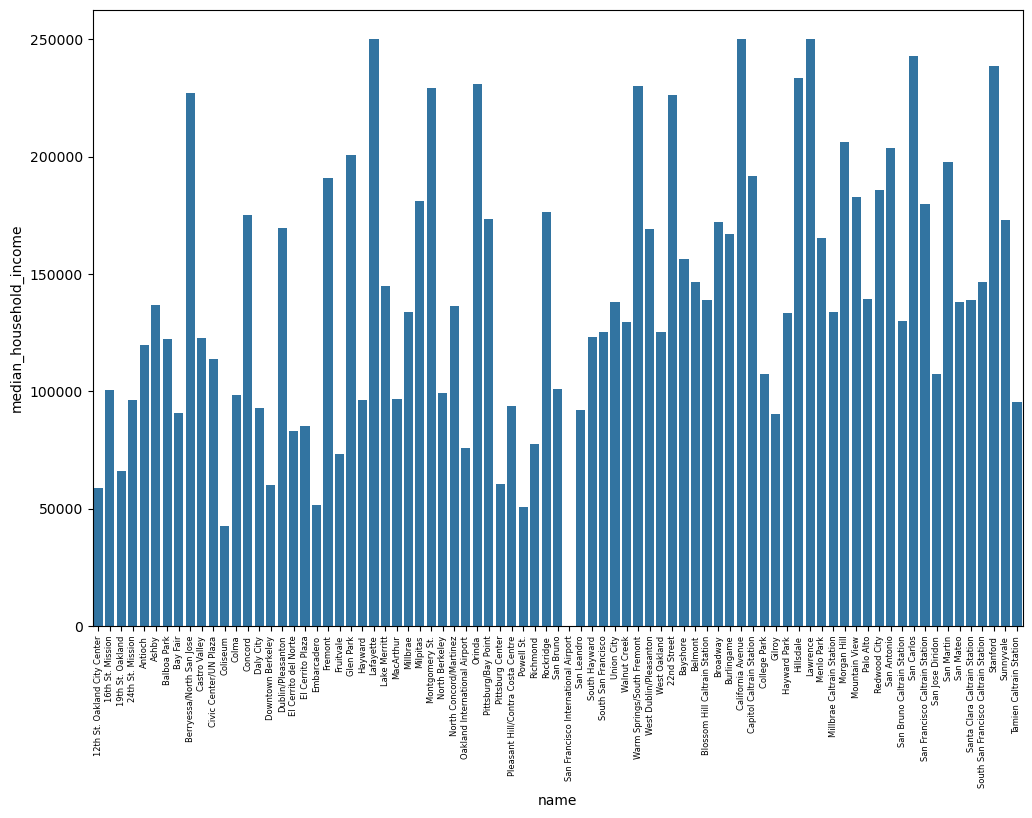

In [46]:
fig, ax = plt.subplots(figsize=(12,8))
sns.barplot(data = transit_census_df, x = "name", y = "median_household_income")
ax.set_xticklabels(transit_census_df['name'].values,rotation = 90, fontsize = 6)
plt.show()


Not seeing where Downtown Berkeley BART station (4325) is causing issues. The values appear reasonable. Could the issues be from the older data before updating to 2024-2025?

## Visualizations

In [63]:
census_gdf = gpd.read_file("../data/census_tract_data_2024.csv")

tracts = gpd.read_file("../data/tl_2024_06_tract/tl_2024_06_tract.shp")
tracts = tracts.to_crs(epsg=3857)

bay_fips = ['001','013','041','055','075','081','085','095','097']

bay_tracts = tracts[
    (tracts['STATEFP'] == '06') &
    (tracts['COUNTYFP'].isin(bay_fips))
]

census = bay_tracts[['GEOID', 'geometry']].merge(census_gdf, on="GEOID")
census

,GEOID,geometry,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state,county,tract,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born
0,06001442700,"POLYGON ((-13582893.983 4514550.527, -13582891...",Census Tract 4427; Alameda County; California,3068,38.6,3068,945,82,0,1464,27,86,464,209625.0,84305.0,3057,90,1071,1071,831,240,1071,9,36,3222.0,1520500.0,1499,876,7,0,0,358,32700.0,1569,1537,32,2165,699,559,89,101,1387,3068,06,001,442700,Alameda,45,4.2,2123,69.2,30.8,2.67,47.72,2.94,22.41,77.59,0.47,58.44,0.0,0.0,23.88,21.81,2.04,1448,66.88,45.21
1,06001442800,"POLYGON ((-13581234.219 4513218.736, -13581226...",Census Tract 4428; Alameda County; California,3041,40.9,3041,846,32,12,1716,0,129,306,179844.0,66720.0,3031,101,953,953,750,203,953,8,5,3250.0,1114100.0,1457,815,32,0,8,380,,1649,1522,127,2275,775,342,40,49,1465,3041,06,001,442800,Alameda,13,1.36,2195,72.18,27.82,1.05,56.43,3.33,21.3,78.7,2.2,55.94,0.0,0.55,26.08,,7.7,1206,53.01,48.17
2,06001442900,"POLYGON ((-13579612.516 4512186.349, -13579602...",Census Tract 4429; Alameda County; California,7783,38.3,7783,924,404,40,4843,13,760,799,172308.0,67357.0,7778,229,2526,2526,1302,1224,2526,34,9,2946.0,1289900.0,4067,2068,342,28,35,1302,89190.0,4512,4188,324,5560,2073,1224,93,77,3754,7783,06,001,442900,Alameda,43,1.7,6859,88.13,11.87,5.19,62.23,2.94,48.46,51.54,8.41,50.85,0.69,0.86,32.01,21.93,7.18,3467,62.36,48.23
3,06095252204,"POLYGON ((-13605096.338 4616602.017, -13605092...",Census Tract 2522.04; Solano County; California,5874,41.3,5874,2231,660,0,1752,18,341,872,199821.0,70224.0,5862,173,1784,1784,1597,187,1784,11,0,3286.0,934500.0,2556,1738,36,4,63,501,68510.0,2823,2543,230,3637,1095,571,73,81,1043,5874,06,095,252204,Solano,11,0.62,3643,62.02,37.98,11.24,29.83,2.95,10.48,89.52,1.41,68.0,0.16,2.46,19.6,26.8,8.15,1820,50.04,17.76
4,06095252203,"POLYGON ((-13601002.303 4624135.025, -13600142...",Census Tract 2522.03; Solano County; California,4299,43.0,4299,1739,344,0,1249,63,54,850,165078.0,78127.0,4296,183,1709,1661,1291,370,1661,14,47,2865.0,813100.0,2258,1575,24,0,46,440,51425.0,2353,2288,34,3100,814,539,132,133,621,4299,06,095,252203,Solano,61,3.67,2560,59.55,40.45,8.0,29.05,4.26,22.28,77.72,1.06,69.75,0.0,2.04,19.49,22.77,1.44,1618,52.19,14.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1767,06013313102,"POLYGON ((-13566949.63 4579335.439, -13566947....",Census Tract 3131.02; Contra Costa County; Cal...,4732,37.8,4732,762,1539,69,724,0,770,868,86165.0,38276.0,4619,629,1669,1611,742,869,1611,12,77,2462.0,576400.0,2307,1943,181,0,33,57,89740.0,2717,2409,308,3255,344,165,0,17,1315,4732,06,013,313102,Contra Costa,89,5.52,3970,83.9,16.1,32.52,15.3,13.62,53.94,46.06,7.85,84.22,0.0,1.43,2.47,38.9,11.34,526,16.16,27.79
1768,06013314102,"POLYGON ((-13573499.441 4583395.627, -13573496...",Census Tract 3141.02; Contra Costa County; Cal...,6523,37.6,6523,1169,389,51,820,26,2737,1331,97429.0,336

In [48]:
mapping = pd.merge(transit, classification[['station_id', 'station_type', 'avg_weekday_exits']], how = "inner", left_on = 'name', 
         right_on='station_id')
mapping

,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county,zipcode,agency,mode,geometry,station_id_y,station_type,avg_weekday_exits
0,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,6900
1,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,4000
2,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,6100
3,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,8200
4,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral,1100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,76,santa_clara,Santa Clara Caltrain Station,37.353384,-121.936465,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-121.936465 37.353384),Santa Clara Caltrain Station,peripheral,1340
77,77,south_sf,South San Francisco Caltrain Station,37.655941,-122.404979,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.404979006 37.655941416),South San Francisco Caltrain Station,peripheral,1070
78,78,stanford,Stanford,37.438950,-122.157150,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.15715 37.43895),Stanford,peripheral,30
79,79,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,NaN,NaN,Caltrain,Commuter Rail,POINT (-122.0315 37.378934),Sunnyvale,peripheral,1930


<Axes: xlabel='agency', ylabel='avg_weekday_exits'>

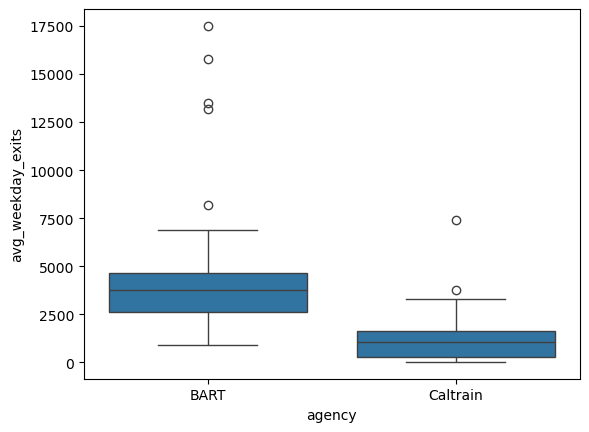

In [49]:
sns.boxplot(data = mapping, x = "agency", y="avg_weekday_exits")

In [52]:
census_transit_class = pd.merge(transit_census_df, classification[['station_id', 'station_type', 'avg_weekday_exits']], how = "inner", left_on = 'station', 
         right_on='station_id')
census_transit_class.head()

,station,geoid,state_x,county_x,tract_x,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry,station_id_y,station_type_x,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state_y,county,tract_y,GEOID,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born,station_id,station_type_y,avg_weekday_exits
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,Census Tract 4030; Alameda County; California,3387,40.4,3387,444,320,2,2178,48,48,347,58794.0,60439.0,3387,799,2413,2034,353,1681,2034,182,1008,2128.0,573000.0,1659,331,440,0,137,707,NaN,1931,1760,171,3024,825,454,67,26,2062,3387,6,1,403000,06001403000,Alameda,1190,58.51,2943,86.89,13.11,9.45,64.30,23.59,82.65,17.35,26.52,19.95,0.00,8.26,42.62,NaN,8.86,1372,45.37,60.88,12th St. Oakland City Center,core,6900
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,Census Tract 201.02; San Francisco County; Cal...,3463,45.0,3463,981,272,57,623,0,1009,521,100761.0,55597.0,3463,948,1861,1306,221,1085,1306,60,639,1764.0,1098000.0,1668,432,315,87,248,467,NaN,2150,1684,466,2885,693,416,33,126,1126,3463,6,75,20102,06075020102,San Francisco,699,53.52,2482,71.67,28.33,7.85,17.99,27.38,83.08,16.92,18.88,25.90,5.22,14.87,28.00,NaN,21.67,1268,43.95,32.52,16th St. Mission,core,4000
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,Census Tract 4029; Alameda County; California,2431,37.2,2431,661,603,10,692,0,112,353,66050.0,89947.0,2417,515,2071,1715,12,1703,1715,0,1029,2096.0,NaN,1496,298,484,19,86,446,NaN,1648,1525,123,2182,829,377,41,85,710,2431,6,1,402900,06001402900,Alameda,1029,60.00,1770,72.81,27.19,24.80,28.47,21.31,99.30,0.70,32.35,19.92,1.27,5.75,29.81,NaN,7.46,1332,61.04,29.21,19th St. Oakland,core,6100
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,Census Tract 209; San Francisco County; Califo...,3746,38.4,3746,1222,38,33,612,0,1170,671,96250.0,67562.0,3733,387,1898,1607,223,1384,1607,50,480,2446.0,1296100.0,2157,438,715,114,101,730,43075.0,2478,2279,199,2979,1144,474,111,156,1180,3746,6,75,20900,06075020900,San Francisco,530,32.98,2524,67.38,32.62,1.01,16.34,10.37,86.12,13.88,33.15,20.31,5.29,4.68,33.84,19.97,8.03,1885,63.28,31.50,24th St. Mission,core,8200
4,Antioch,06013308002,06,013,308002,Census Tract 3080.02,4,ANTC,Antioch,37.995388,-121.780420,1600 Slatten Ranch Road,Antioch,Contra Costa,94509.0,BART,Heavy Rail,POINT (-121.78042 37.995388),Antioch,peripheral

<Axes: xlabel='total_pop', ylabel='avg_weekday_exits'>

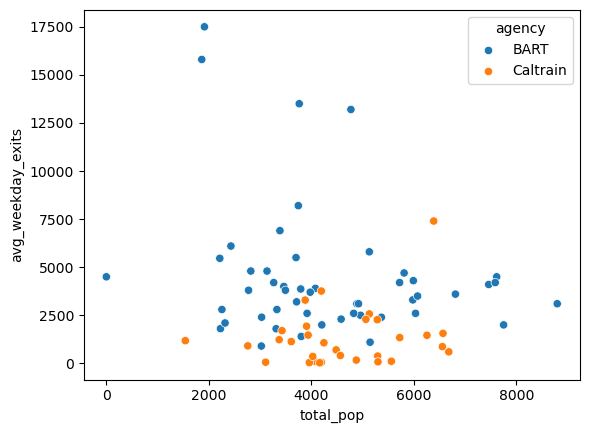

In [54]:
sns.scatterplot(
    x="total_pop",
    y="avg_weekday_exits",
    hue="agency",
    data = census_transit_class
)

<Axes: xlabel='median_household_income', ylabel='avg_weekday_exits'>

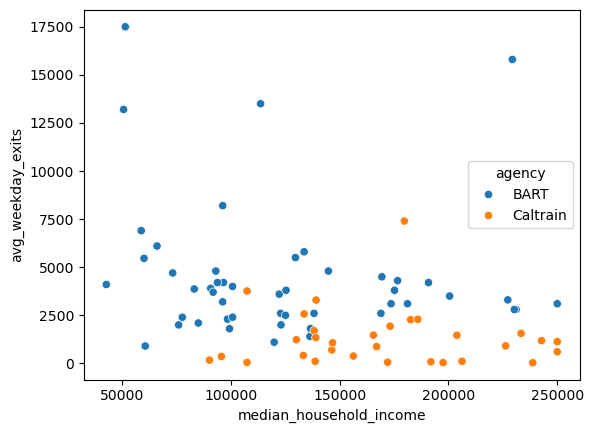

In [55]:
sns.scatterplot(
    x="median_household_income",
    y="avg_weekday_exits",
    hue="agency",
    data = census_transit_class
)

In [65]:
full = census_transit_class.merge(census[['GEOID', 'geometry']], how = 'left', left_on='geoid', right_on='GEOID')
full

,station,geoid,state_x,county_x,tract_x,tract_name,Unnamed: 0,station_id_x,name,latitude,longitude,address,city,county_y,zipcode,agency,mode,geometry_x,station_id_y,station_type_x,NAME,total_pop,median_age,total_pop_race,white_alone,black_alone,aian_alone,asian_alone,nhpi_alone,other_race_alone,two_or_more_races,median_household_income,per_capita_income,total_pop_poverty_calc,pop_below_poverty,total_housing_units,total_occupied_units,owner_occupied,renter_occupied,total_households,owner_occ_no_vehicle,renter_occ_no_vehicle,median_gross_rent,median_home_value,total_workers_16plus,drove_alone,public_transit_commuters,bicycle_commuters,walked_commuters,worked_from_home,aggregate_travel_time_mins,labor_force,employed,unemployed,pop_25plus,bachelors_degree,masters_degree,professional_degree,doctorate_degree,foreign_born,total_pop_nativity,state_y,county,tract_y,GEOID_x,county_name,households_no_vehicle,pct_no_vehicle,pop_nonwhite,pct_nonwhite,pct_white,pct_black,pct_asian,poverty_rate,pct_renter,pct_owner,pct_transit_commute,pct_drove_alone,pct_bike_commute,pct_walk_commute,pct_wfh,mean_travel_time_mins,unemployment_rate,pop_bachelors_plus,pct_bachelors_plus,pct_foreign_born,station_id,station_type_y,avg_weekday_exits,GEOID_y,geometry_y
0,12th St. Oakland City Center,06001403000,06,001,403000,Census Tract 4030,0,12TH,12th St. Oakland City Center,37.803768,-122.271450,1245 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.27145 37.803768),12th St. Oakland City Center,core,Census Tract 4030; Alameda County; California,3387,40.4,3387,444,320,2,2178,48,48,347,58794.0,60439.0,3387,799,2413,2034,353,1681,2034,182,1008,2128.0,573000.0,1659,331,440,0,137,707,NaN,1931,1760,171,3024,825,454,67,26,2062,3387,6,1,403000,06001403000,Alameda,1190,58.51,2943,86.89,13.11,9.45,64.30,23.59,82.65,17.35,26.52,19.95,0.00,8.26,42.62,NaN,8.86,1372,45.37,60.88,12th St. Oakland City Center,core,6900,06001403000,"POLYGON ((-13611590.818 4550988.94, -13611580...."
1,16th St. Mission,06075020102,06,075,020102,Census Tract 201.02,1,16TH,16th St. Mission,37.765062,-122.419694,2000 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.419694 37.765062),16th St. Mission,core,Census Tract 201.02; San Francisco County; Cal...,3463,45.0,3463,981,272,57,623,0,1009,521,100761.0,55597.0,3463,948,1861,1306,221,1085,1306,60,639,1764.0,1098000.0,1668,432,315,87,248,467,NaN,2150,1684,466,2885,693,416,33,126,1126,3463,6,75,20102,06075020102,San Francisco,699,53.52,2482,71.67,28.33,7.85,17.99,27.38,83.08,16.92,18.88,25.90,5.22,14.87,28.00,NaN,21.67,1268,43.95,32.52,16th St. Mission,core,4000,06075020102,"POLYGON ((-13627959.726 4546498.189, -13627902..."
2,19th St. Oakland,06001402900,06,001,402900,Census Tract 4029,2,19TH,19th St. Oakland,37.808350,-122.268602,1900 Broadway,Oakland,alameda,94612.0,BART,Heavy Rail,POINT (-122.268602 37.80835),19th St. Oakland,core,Census Tract 4029; Alameda County; California,2431,37.2,2431,661,603,10,692,0,112,353,66050.0,89947.0,2417,515,2071,1715,12,1703,1715,0,1029,2096.0,NaN,1496,298,484,19,86,446,NaN,1648,1525,123,2182,829,377,41,85,710,2431,6,1,402900,06001402900,Alameda,1029,60.00,1770,72.81,27.19,24.80,28.47,21.31,99.30,0.70,32.35,19.92,1.27,5.75,29.81,NaN,7.46,1332,61.04,29.21,19th St. Oakland,core,6100,06001402900,"POLYGON ((-13611176.038 4551825.521, -13611160..."
3,24th St. Mission,06075020900,06,075,020900,Census Tract 209,3,24TH,24th St. Mission,37.752470,-122.418143,2800 Mission Street,San Francisco,sanfrancisco,94110.0,BART,Heavy Rail,POINT (-122.418143 37.75247),24th St. Mission,core,Census Tract 209; San Francisco County; Califo...,3746,38.4,3746,1222,38,33,612,0,1170,671,96250.0,67562.0,3733,387,1898,1607,223,1384,1607,50,480,2446.0,1296100.0,2157,438,715,114,101,730,43075.0,2478,2279,199,2979,1144,474,111,156,1180,3746,6,75,20900,06075020900,San Francisco,530,32.98,2524,67.38,32.62,1.01,16.34,10.37,86.12,13.88,33.15,20.31,5.29,4.68,33.84,19.97,8.03,1885,63.28,31.50,24th St. Mission,core,

In [66]:
full_gdf = gpd.GeoDataFrame(
    full, 
    geometry= 'geometry_y',
    crs="EPSG:3857" # WGS84
)

<Axes: >

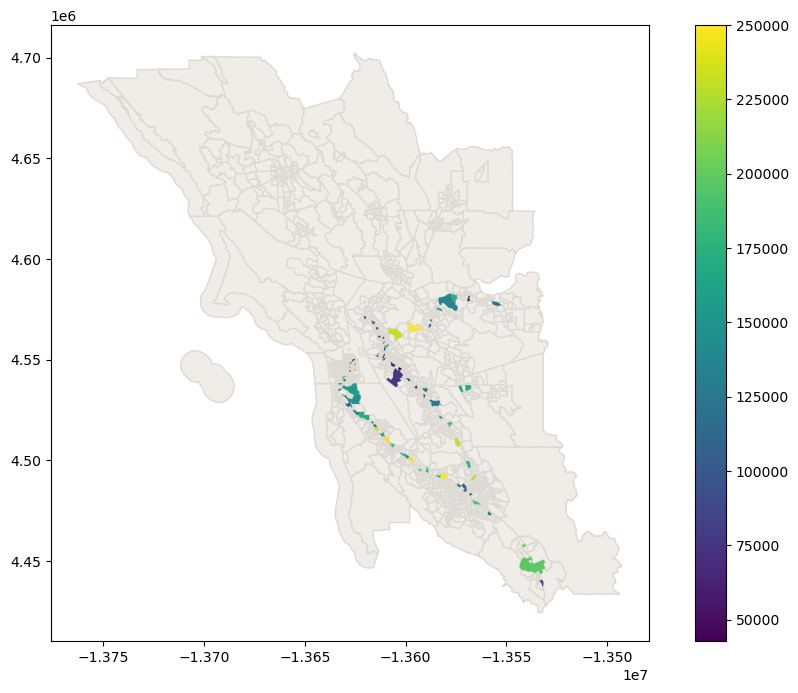

In [71]:
fig, ax = plt.subplots(figsize=(12, 8))
census.plot(ax = ax, color="#F0EDE8", edgecolor="#DDD9D3")
full_gdf.plot(ax = ax, column="median_household_income", cmap="viridis", legend = True)

<Axes: >

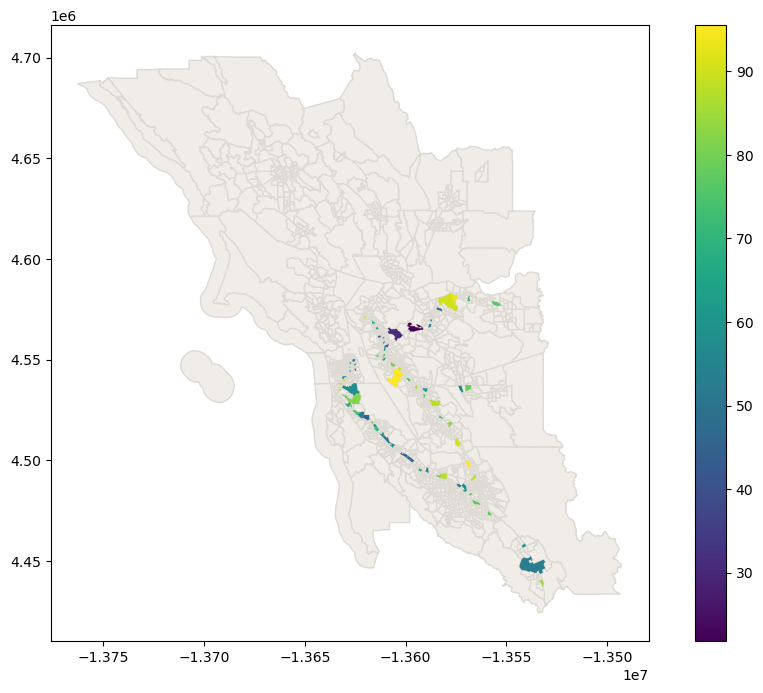

In [72]:
fig, ax = plt.subplots(figsize=(12, 8))
census.plot(ax = ax, color="#F0EDE8", edgecolor="#DDD9D3")
full_gdf.plot(ax = ax, column="pct_nonwhite", cmap="viridis", legend = True)

<Axes: >

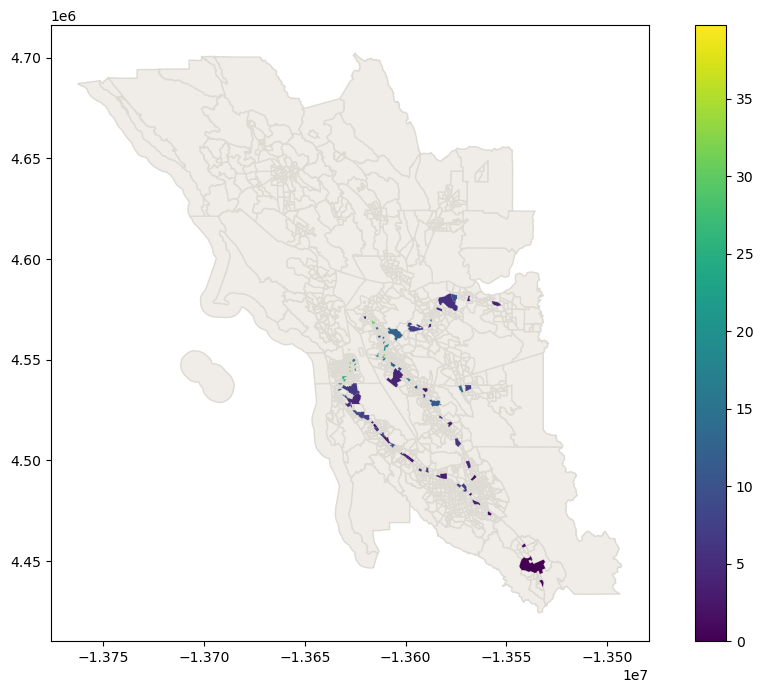

In [75]:
fig, ax = plt.subplots(figsize=(12, 8))
census.plot(ax = ax, color="#F0EDE8", edgecolor="#DDD9D3")
full_gdf.plot(ax = ax, column="pct_transit_commute", cmap="viridis", legend = True)

In [73]:
full_gdf.explore(column="median_household_income", cmap="viridis", legend = True)

In [76]:
full_gdf.columns

Index(['station', 'geoid', 'state_x', 'county_x', 'tract_x', 'tract_name',
       'Unnamed: 0', 'station_id_x', 'name', 'latitude', 'longitude',
       'address', 'city', 'county_y', 'zipcode', 'agency', 'mode',
       'geometry_x', 'station_id_y', 'station_type_x', 'NAME', 'total_pop',
       'median_age', 'total_pop_race', 'white_alone', 'black_alone',
       'aian_alone', 'asian_alone', 'nhpi_alone', 'other_race_alone',
       'two_or_more_races', 'median_household_income', 'per_capita_income',
       'total_pop_poverty_calc', 'pop_below_poverty', 'total_housing_units',
       'total_occupied_units', 'owner_occupied', 'renter_occupied',
       'total_households', 'owner_occ_no_vehicle', 'renter_occ_no_vehicle',
       'median_gross_rent', 'median_home_value', 'total_workers_16plus',
       'drove_alone', 'public_transit_commuters', 'bicycle_commuters',
       'walked_commuters', 'worked_from_home', 'aggregate_travel_time_mins',
       'labor_force', 'employed', 'unemployed', 'pop_25

<Axes: >

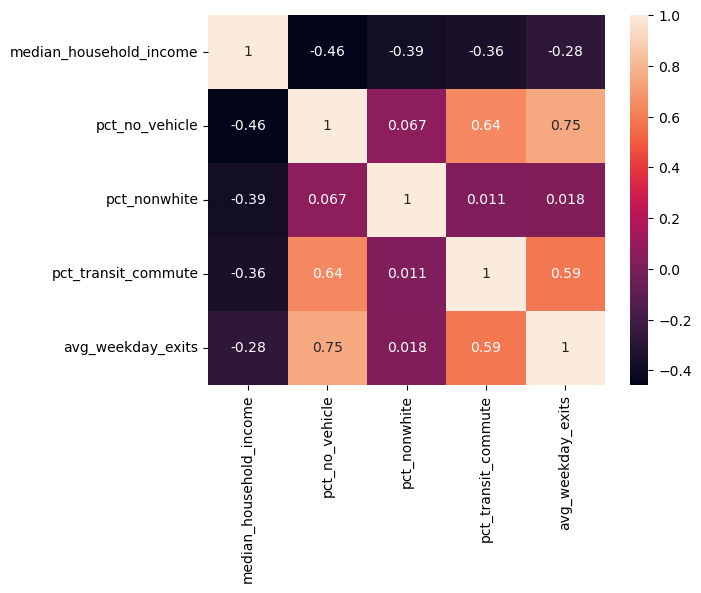

In [ ]:
variables = ["median_household_income", 
             "pct_no_vehicle", 
             "pct_nonwhite", 
             "pct_transit_commute", 
             "avg_weekday_exits"]

sns.heatmap(data = full_gdf[variables].corr(), annot=True)


In [85]:
summary = full_gdf.groupby('station_type_y')[variables].mean()
summary

,median_household_income,pct_no_vehicle,pct_nonwhite,pct_transit_commute,avg_weekday_exits
station_type_y,,,,,
core,119815.483871,25.971290,69.496452,17.166452,5943.062500
peripheral,156611.755102,7.207959,66.732041,6.488163,1524.142857


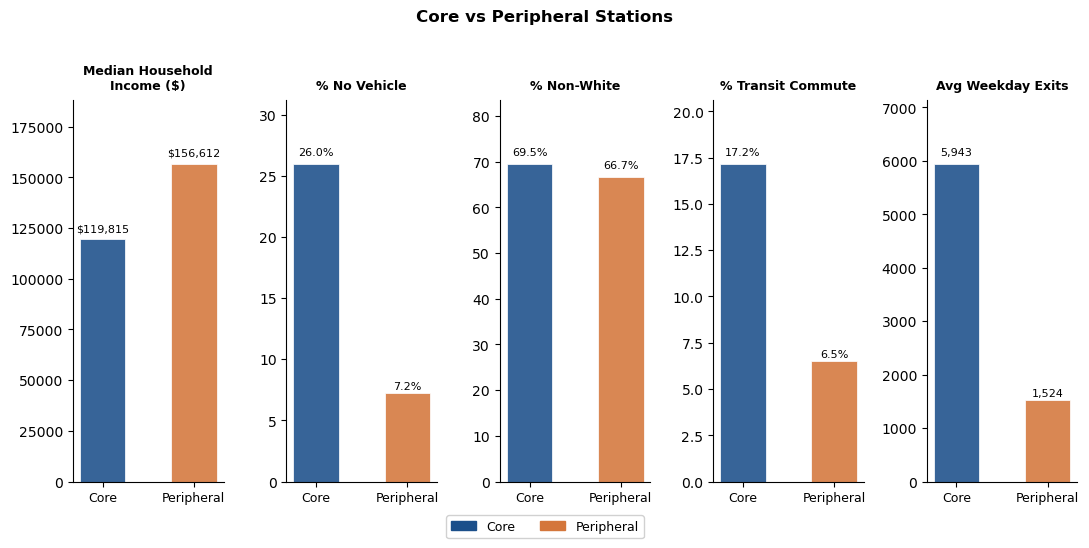

In [92]:
COLORS = {"core": "#1B4F8A", "peripheral": "#D4763B"}
 
labels = {
    "median_household_income": "Median Household\nIncome ($)",
    "pct_no_vehicle":          "% No Vehicle",
    "pct_nonwhite":            "% Non-White",
    "pct_transit_commute":     "% Transit Commute",
    "avg_weekday_exits":       "Avg Weekday Exits",
}

variables = list(labels.keys())
x         = np.arange(len(variables))
width     = 0.35
 
fig, axes = plt.subplots(1, len(variables), figsize=(11, 5))
 
for ax, var in zip(axes, variables):
    for i, (group, color) in enumerate(COLORS.items()):
        val  = summary.loc[group, var]
        bar  = ax.bar(i, val, color=color, alpha=0.88,
                      edgecolor="white", linewidth=0.6, width=0.5)
 
        # Format value label based on variable type
        if "income" in var:
            fmt = f"${val:,.0f}"
        elif "exits" in var:
            fmt = f"{val:,.0f}"
        else:
            fmt = f"{val:.1f}%"
 
        ax.text(i, val + val * 0.02, fmt,
                ha="center", va="bottom", fontsize=8)
 
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Core", "Peripheral"], fontsize=9)
    ax.set_title(labels[var], fontsize=9, fontweight="bold", pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, max(summary[var]) * 1.2)   # consistent headroom for labels
 
# Shared legend
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=COLORS["core"],       label="Core"),
    plt.Rectangle((0, 0), 1, 1, color=COLORS["peripheral"],  label="Peripheral"),
]
fig.legend(handles=legend_patches, loc="lower center",
           ncol=2, fontsize=9, framealpha=0.9,
           bbox_to_anchor=(0.5, -0.05))
 
fig.suptitle("Core vs Peripheral Stations",
             fontsize=12, fontweight="bold", y=1.02)
 
plt.tight_layout()